# Project 6 | Notebook 1: Data Acquisition and Exploration

## Overview

This notebook is the first in a four-notebook pipeline for Project 6 of the
BRICS-Trade-Labour-Portfolio. The project maps structural change — the shift
from agricultural to non-farm employment — across Indian districts between
1990 and 2013, and examines whether that variation correlates spatially with
proximity to trade infrastructure.

This notebook covers five stages:

1. **Environment setup** — import libraries, confirm versions, set display options
2. **Shapefile loading** — load and inspect the Census 2011 district boundary file
3. **SHRUG data loading** — load and inspect the Economic Census and Population
   Census Abstract modules
4. **Boundary harmonisation and merge** — aggregate all data to 2011 district
   boundaries and merge with the shapefile geometry
5. **First exploratory choropleth** — produce an initial map to verify the merge
   and build spatial intuition

**Input data:**
- `data/raw/shapefiles/2011_Dist.shp` — Census 2011 district boundaries (DataMeet)
- `data/raw/shrug/shrug-ec13-csv/ec13_pc11dist.csv` — 2013 Economic Census, district level
- `data/raw/shrug/shrug-ec05-csv/ec05_pc01dist.csv` — 2005 Economic Census, district level
- `data/raw/shrug/shrug-ec90-csv/ec90_pc91dist.csv` — 1990 Economic Census, district level
- `data/raw/shrug/shrug-ec98-csv/ec98_shrid.csv` — 1998 Economic Census, shrid level only
- `data/raw/shrug/shrug-pca11-csv/pc11_pca_clean_pc11dist.csv` — 2011 Population Census
- `data/raw/shrug/shrug-pca01-csv/pc01_pca_clean_pc01dist.csv` — 2001 Population Census
- `data/raw/shrug/shrug-pca91-csv/pc91_pca_clean_pc91dist.csv` — 1991 Population Census
- `data/raw/shrug/shrug-pc-keys-csv/shrid_pc11dist_key.csv` — shrid → 2011 district key

**Output:**
- `data/processed/districts_structural_change.gpkg` — merged district-level
  GeoDataFrame with geometry and socioeconomic variables, ready for Notebook 2

In [2]:
# ─────────────────────────────────────────────────────────────
# Project 6 | Notebook 1: Stage 1 — Environment Setup
# ─────────────────────────────────────────────────────────────

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

# ── Display settings ──────────────────────────────────────────
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')

# ── Project paths ─────────────────────────────────────────────
PROJECT_ROOT = Path('..') 
DATA_RAW     = PROJECT_ROOT / 'data' / 'raw'
DATA_PROC    = PROJECT_ROOT / 'data' / 'processed'
FIGURES      = PROJECT_ROOT / 'figures'

# Create processed and figures directories if they don't exist yet
DATA_PROC.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

# ── Version check ─────────────────────────────────────────────
print(f"pandas     : {pd.__version__}")
print(f"geopandas  : {gpd.__version__}")
print(f"matplotlib : {plt.matplotlib.__version__}")
print(f"\nProject root : {PROJECT_ROOT.resolve()}")
print(f"Data raw     : {DATA_RAW.resolve()}")
print(f"Data processed: {DATA_PROC.resolve()}")

pandas     : 2.3.3
geopandas  : 1.0.1
matplotlib : 3.9.4

Project root : /Users/psat0501/Desktop/UZH/Pre-Doc/Prep/BRICS-Trade-Labour-Portfolio/06_trade_exposure_maps
Data raw     : /Users/psat0501/Desktop/UZH/Pre-Doc/Prep/BRICS-Trade-Labour-Portfolio/06_trade_exposure_maps/data/raw
Data processed: /Users/psat0501/Desktop/UZH/Pre-Doc/Prep/BRICS-Trade-Labour-Portfolio/06_trade_exposure_maps/data/processed


## Stage 1 — Output

Libraries loaded successfully:
- pandas 2.3.3
- geopandas 1.0.1
- matplotlib 3.9.4

All project paths resolve correctly. The `processed/` and `figures/` 
directories are confirmed present. Ready to load data.

## Stage 2 — Load and Inspect the District Shapefile

A shapefile is a collection of files that together describe the geometry 
of geographic features — in our case, the polygon boundary of each Indian 
district. `geopandas.read_file()` reads all the component files (`.shp`, 
`.dbf`, `.prj`, `.shx`) together and returns a GeoDataFrame.

A GeoDataFrame is identical to a pandas DataFrame except it has one special 
column called `geometry` that stores the polygon shape for each row. Every 
other column contains regular attribute data — district name, state name, 
census codes, etc.

We first inspect the shapefile to understand:
- How many districts are present (should be ~640 for Census 2011)
- What columns are available (we need district and state identifiers)
- What the coordinate reference system (CRS) is
- What the data looks like visually

In [3]:
# ─────────────────────────────────────────────────────────────
# Stage 2 — Load and inspect district shapefile
# ─────────────────────────────────────────────────────────────

SHAPEFILE = DATA_RAW / 'shapefiles' / '2011_Dist.shp'

# Load shapefile into a GeoDataFrame
gdf = gpd.read_file(SHAPEFILE)

# ── Basic inspection ──────────────────────────────────────────
print(f"Shape        : {gdf.shape}")
print(f"CRS          : {gdf.crs}")
print(f"\nColumn names :\n{gdf.columns.tolist()}")
print(f"\nFirst 5 rows :")
gdf.head()

Shape        : (641, 6)
CRS          : EPSG:4326

Column names :
['DISTRICT', 'ST_NM', 'ST_CEN_CD', 'DT_CEN_CD', 'censuscode', 'geometry']

First 5 rows :


,DISTRICT,ST_NM,ST_CEN_CD,DT_CEN_CD,censuscode,geometry
0,Adilabad,Andhra Pradesh,28,1,532,"POLYGON ((78.84972 19.7601, 78.85102 19.75945,..."
1,Agra,Uttar Pradesh,9,15,146,"POLYGON ((78.19803 27.4028, 78.19804 27.40278,..."
2,Ahmadabad,Gujarat,24,7,474,"MULTIPOLYGON (((72.03456 23.50527, 72.03337 23..."
3,Ahmadnagar,Maharashtra,27,26,522,"POLYGON ((74.67333 19.9467, 74.67393 19.93509,..."
4,Aizawl,Mizoram,15,3,283,"POLYGON ((92.98749 24.40453, 92.99107 24.40236..."


### Stage 2 — Output

The shapefile loaded successfully with 641 district polygons.

- **CRS:** EPSG:4326 (WGS84) — standard lat/lon, correct for storage
- **Districts:** 641 rows (Census 2011 has 640 districts; the extra row
  is likely a disputed territory or union territory boundary)
- **Key identifier:** `censuscode` — a unique numeric code per district
  that we will use to join SHRUG employment data to this geometry
- **Geometry types:** Mix of POLYGON and MULTIPOLYGON — some districts
  have non-contiguous parts (e.g. islands, enclaves), which geopandas
  handles natively

The joining strategy will be: match `censuscode` in this shapefile to
the district identifier column in the SHRUG `ec13_pc11dist.csv` file.
We verify this in Stage 3.

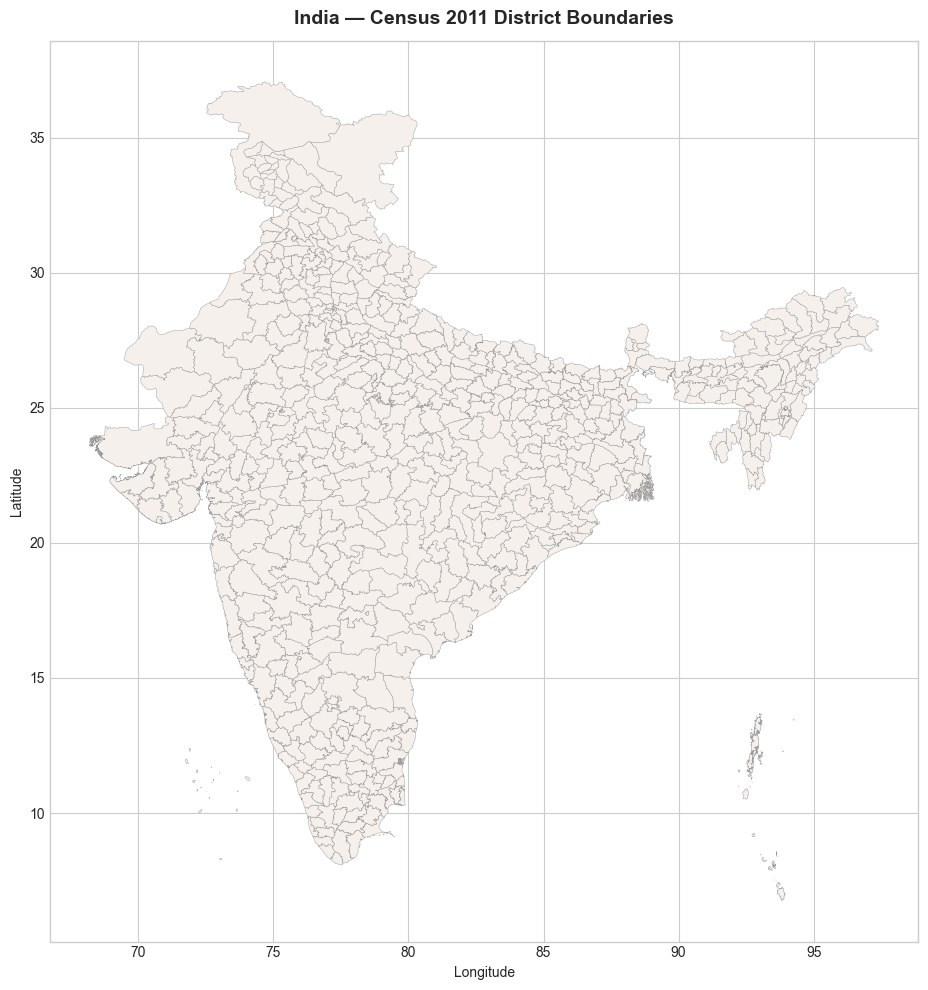

Figure saved to: ../figures/stage2_district_boundaries.png


In [4]:
# ─────────────────────────────────────────────────────────────
# Stage 2 — Plot district boundaries (no data, outlines only)
# ─────────────────────────────────────────────────────────────

fig, ax = plt.subplots(1, 1, figsize=(14, 10))

gdf.plot(
    ax=ax,
    color='#f5f0eb',       # light warm fill
    edgecolor='#999999',   # grey boundaries
    linewidth=0.3
)

ax.set_title('India — Census 2011 District Boundaries', 
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Longitude', fontsize=10)
ax.set_ylabel('Latitude', fontsize=10)
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig(FIGURES / 'stage2_district_boundaries.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Figure saved to: {FIGURES / 'stage2_district_boundaries.png'}")

### Stage 2 — Map Output

The boundary map confirms the shapefile is complete and correctly georeferenced.
Visible features:
- Jammu & Kashmir and Ladakh in the north
- Dense district grid across the Indo-Gangetic plain (UP, Bihar)
- Northeast states (Assam, Meghalaya, Manipur etc.) visible on the right
- Andaman & Nicobar Islands (bottom right) and Lakshadweep (bottom left)
  appear as small island polygons — these are union territories with no
  Economic Census data in SHRUG and will drop out naturally during the merge

The map is stored at EPSG:4326 (lat/lon), which is why the proportions
look slightly compressed east-west. This is normal for unprojected display.
Figure saved to `figures/stage2_district_boundaries.png`.

## Stage 3 — Load and Inspect SHRUG Data

We load three Economic Census rounds and three Population Census Abstract
rounds. For each file we inspect:
- Number of rows and columns
- The district identifier column (which we need to match to `censuscode`
  in the shapefile)
- The employment and population variables available

The critical question for each file is: **what is the district identifier
column called, and does its values match `censuscode` in the shapefile?**

We start with the most recent and cleanest round — EC 2013 — since it is
already aggregated to 2011 Census district boundaries, the same vintage
as our shapefile. This is the round that will merge directly with no
crosswalk needed.

In [5]:
# ─────────────────────────────────────────────────────────────
# Stage 3 — Load EC 2013 (district level, 2011 boundaries)
# ─────────────────────────────────────────────────────────────

ec13 = pd.read_csv(DATA_RAW / 'shrug' / 'shrug-ec13-csv' / 'ec13_pc11dist.csv')

print(f"Shape        : {ec13.shape}")
print(f"\nColumn names :\n{ec13.columns.tolist()}")
print(f"\nFirst 3 rows :")
ec13.head(3)

Shape        : (640, 140)

Column names :
['pc11_state_id', 'pc11_district_id', 'ec13_emp_all', 'ec13_emp_f', 'ec13_emp_m', 'ec13_emp_hired', 'ec13_emp_hired_m', 'ec13_emp_hired_f', 'ec13_emp_unhired', 'ec13_emp_unhired_m', 'ec13_emp_unhired_f', 'ec13_emp_gov', 'ec13_emp_priv', 'ec13_emp_own_m', 'ec13_emp_own_f', 'ec13_emp_own_other', 'ec13_emp_pub_banks', 'ec13_emp_pub_mines', 'ec13_emp_size20', 'ec13_emp_size50', 'ec13_emp_size100', 'ec13_emp_size101', 'ec13_emp_st', 'ec13_emp_sc', 'ec13_emp_obc', 'ec13_emp_other', 'ec13_count_all', 'ec13_count_f', 'ec13_count_m', 'ec13_count_gov', 'ec13_count_priv', 'ec13_count_own_m', 'ec13_count_own_f', 'ec13_count_own_other', 'ec13_count_pub_banks', 'ec13_count_pub_mines', 'ec13_count_size20', 'ec13_count_size50', 'ec13_count_size100', 'ec13_count_size101', 'ec13_count_st', 'ec13_count_sc', 'ec13_count_obc', 'ec13_count_other', 'ec13_emp_manuf', 'ec13_emp_services', 'ec13_emp_shric_1', 'ec13_emp_shric_2', 'ec13_emp_shric_3', 'ec13_emp_shric_4', '

,pc11_state_id,pc11_district_id,ec13_emp_all,ec13_emp_f,ec13_emp_m,ec13_emp_hired,ec13_emp_hired_m,ec13_emp_hired_f,ec13_emp_unhired,ec13_emp_unhired_m,ec13_emp_unhired_f,ec13_emp_gov,ec13_emp_priv,ec13_emp_own_m,ec13_emp_own_f,ec13_emp_own_other,ec13_emp_pub_banks,ec13_emp_pub_mines,ec13_emp_size20,ec13_emp_size50,ec13_emp_size100,ec13_emp_size101,ec13_emp_st,ec13_emp_sc,ec13_emp_obc,...,ec13_emp_shric_70,ec13_emp_shric_71,ec13_emp_shric_72,ec13_emp_shric_73,ec13_emp_shric_74,ec13_emp_shric_75,ec13_emp_shric_76,ec13_emp_shric_77,ec13_emp_shric_78,ec13_emp_shric_79,ec13_emp_shric_80,ec13_emp_shric_81,ec13_emp_shric_82,ec13_emp_shric_83,ec13_emp_shric_84,ec13_emp_shric_85,ec13_emp_shric_86,ec13_emp_shric_87,ec13_emp_shric_88,ec13_emp_shric_89,ec13_emp_shric_90,_mean_p_miss,_core_p_miss,_target_weight_share,_target_group_max_weight_share
0,1,1,43585.0000,7360.0000,36225.0000,25451.0000,19233.0000,6218.0000,18134.0000,16992.0000,1142.0000,12654.0000,30931.0000,23075.0000,1590.0000,164.0000,255.0000,9.0000,41462.0000,1953.0000,170.0000,0.0000,370.0000,326.0000,3039.0000,...,3.0000,1.0000,1545.0000,103.0000,0.0000,7.0000,3.0000,14.0000,4.0000,9.0000,9863.0000,3863.0000,160.0000,333.0000,9.0000,3402.0000,13.0000,975.0000,13.0000,143.0000,1011.0000,NaN,NaN,NaN,NaN
1,1,2,91532.0000,23292.0000,68240.0000,30709.0000,22728.0000,7981.0000,60823.0000,45512.0000,15311.0000,10908.0000,80624.0000,64829.0000,7128.0000,693.0000,334.0000,13.0000,82063.0000,3215.0000,1448.0000,4806.0000,896.0000,175.0000,12442.0000,...,4.0000,153.0000,2516.0000,29.0000,10.0000,7.0000,0.0000,23.0000,8.0000,0.0000,7663.0000,3227.0000,291.0000,13.0000,6.0000,1933.0000,25.0000,1311.0000,25.0000,144.0000,711.0000,NaN,NaN,NaN,NaN
2,1,3,18508.0000,5606.0000,12902.0000,10800.0000,6901.0000,3899.0000,7708.0000,6001.0000,1707.0000,4072.0000,14436.0000,10593.0000,1639.0000,52.0000,148.0000,0.0000,15627.0000,1957.0000,500.0000,424.0000,8753.0000,154.0000,73.0000,...,22.0000,22.0000,339.0000,55.0000,0.0000,0.0000,8.0000,0.0000,0.0000,0.0000,3447.0000,1084.0000,109.0000,84.0000,14.0000,35.0000,47.0000,230.0000,29.0000,58.0000,520.0000,NaN,NaN,NaN,NaN


### Stage 3a — EC 2013 Output

The 2013 Economic Census district file loaded with 640 rows — exactly
matching Census 2011 district count. Key findings:

- **District identifier:** Two-part key — `pc11_state_id` (state code) +
  `pc11_district_id` (district code within state). We need to verify
  whether this combination matches the `censuscode` column in the shapefile.
- **Primary variables for analysis:**
  - `ec13_emp_all` — total non-farm employment
  - `ec13_emp_manuf` — manufacturing employment
  - `ec13_emp_services` — services employment
- **Industry detail:** Columns `ec13_emp_shric_1` through `ec13_emp_shric_90`
  provide employment by SHRUG industrial classification — available for
  potential extension but not used in this analysis
- **Quality flags:** `_mean_p_miss` and `_core_p_miss` indicate imputation
  rates; rows with high missingness will be flagged in the merge assessment

In [6]:
# ─────────────────────────────────────────────────────────────
# Stage 3 — Verify join key: does censuscode match SHRUG ids?
# ─────────────────────────────────────────────────────────────

# Inspect the identifier ranges in SHRUG
print("SHRUG EC13 — identifier ranges:")
print(f"  pc11_state_id    : min={ec13['pc11_state_id'].min()}, "
      f"max={ec13['pc11_state_id'].max()}, "
      f"unique={ec13['pc11_state_id'].nunique()}")
print(f"  pc11_district_id : min={ec13['pc11_district_id'].min()}, "
      f"max={ec13['pc11_district_id'].max()}, "
      f"unique={ec13['pc11_district_id'].nunique()}")

# Inspect the identifier in the shapefile
print(f"\nShapefile — censuscode range:")
print(f"  censuscode : min={gdf['censuscode'].min()}, "
      f"max={gdf['censuscode'].max()}, "
      f"unique={gdf['censuscode'].nunique()}")
print(f"  ST_CEN_CD  : min={gdf['ST_CEN_CD'].min()}, "
      f"max={gdf['ST_CEN_CD'].max()}, "
      f"unique={gdf['ST_CEN_CD'].nunique()}")
print(f"  DT_CEN_CD  : min={gdf['DT_CEN_CD'].min()}, "
      f"max={gdf['DT_CEN_CD'].max()}, "
      f"unique={gdf['DT_CEN_CD'].nunique()}")

# Check if ST_CEN_CD matches pc11_state_id
shrug_states = set(ec13['pc11_state_id'].unique())
shp_states   = set(gdf['ST_CEN_CD'].unique())
print(f"\nState codes in SHRUG but not shapefile : {shrug_states - shp_states}")
print(f"State codes in shapefile but not SHRUG : {shp_states - shrug_states}")

SHRUG EC13 — identifier ranges:
  pc11_state_id    : min=1, max=35, unique=35
  pc11_district_id : min=1, max=640, unique=640

Shapefile — censuscode range:
  censuscode : min=0, max=640, unique=641
  ST_CEN_CD  : min=1, max=99, unique=36
  DT_CEN_CD  : min=1, max=99, unique=72

State codes in SHRUG but not shapefile : set()
State codes in shapefile but not SHRUG : {np.int32(99)}


### Stage 3b — Join Key Verification Output

Key findings:

- `pc11_district_id` in SHRUG (range 1–640) maps directly to `censuscode`
  in the shapefile (range 0–640). The `censuscode == 0` row in the shapefile
  corresponds to disputed territories (state code 99) which have no SHRUG
  data and will drop out naturally during the merge.
- `ST_CEN_CD == 99` in the shapefile represents disputed territories
  (e.g. Aksai Chin) — not present in SHRUG. This accounts for the 641 vs
  640 row discrepancy.
- **Join key confirmed:** `pc11_district_id` (SHRUG) = `censuscode`
  (shapefile). No composite key construction needed.

In [7]:
# ─────────────────────────────────────────────────────────────
# Stage 3 — Load remaining EC and PCA files, inspect identifiers
# ─────────────────────────────────────────────────────────────

# Economic Census rounds
ec90 = pd.read_csv(DATA_RAW / 'shrug' / 'shrug-ec90-csv' / 'ec90_pc91dist.csv')
ec05 = pd.read_csv(DATA_RAW / 'shrug' / 'shrug-ec05-csv' / 'ec05_pc01dist.csv')

# Population Census Abstract rounds
pca91 = pd.read_csv(DATA_RAW / 'shrug' / 'shrug-pca91-csv' / 'pc91_pca_clean_pc91dist.csv')
pca01 = pd.read_csv(DATA_RAW / 'shrug' / 'shrug-pca01-csv' / 'pc01_pca_clean_pc01dist.csv')
pca11 = pd.read_csv(DATA_RAW / 'shrug' / 'shrug-pca11-csv' / 'pc11_pca_clean_pc11dist.csv')

# Summarise each file
files = {
    'EC 1990 (pc91dist)' : ec90,
    'EC 2005 (pc01dist)' : ec05,
    'PCA 1991'           : pca91,
    'PCA 2001'           : pca01,
    'PCA 2011'           : pca11,
}

for name, df in files.items():
    id_cols = [c for c in df.columns if 'state' in c or 'district' in c]
    print(f"\n{'─'*50}")
    print(f"{name}")
    print(f"  Shape      : {df.shape}")
    print(f"  ID columns : {id_cols}")
    for col in id_cols:
        print(f"    {col}: min={df[col].min()}, max={df[col].max()}, "
              f"unique={df[col].nunique()}")


──────────────────────────────────────────────────
EC 1990 (pc91dist)
  Shape      : (425, 129)
  ID columns : ['pc91_state_id', 'pc91_district_id']
    pc91_state_id: min=2, max=33, unique=29
    pc91_district_id: min=1, max=63, unique=63

──────────────────────────────────────────────────
EC 2005 (pc01dist)
  Shape      : (591, 138)
  ID columns : ['pc01_state_id', 'pc01_district_id']
    pc01_state_id: min=1, max=35, unique=35
    pc01_district_id: min=1, max=70, unique=70

──────────────────────────────────────────────────
PCA 1991
  Shape      : (452, 59)
  ID columns : ['pc91_state_id', 'pc91_district_id']
    pc91_state_id: min=2, max=33, unique=31
    pc91_district_id: min=1, max=63, unique=63

──────────────────────────────────────────────────
PCA 2001
  Shape      : (593, 57)
  ID columns : ['pc01_state_id', 'pc01_district_id']
    pc01_state_id: min=1, max=35, unique=35
    pc01_district_id: min=1, max=70, unique=70

──────────────────────────────────────────────────
PCA 20

In [ ]:
### Stage 3c — Multi-Round File Inspection Output

This output reveals the boundary harmonisation challenge in full:

**EC 2013 / PCA 2011** use a unified all-India district identifier
(`pc11_district_id`, range 1–640) that maps directly to `censuscode`
in the shapefile. No crosswalk needed.

**EC 2005 / PCA 2001** use a within-state district identifier
(`pc01_district_id`, max 70 per state, across 35 states). The 591/593
row count reflects 2001 Census district coverage. These cannot be merged
directly to the shapefile — a crosswalk via SHRUG key files is required.

**EC 1990 / PCA 1991** use a within-state district identifier
(`pc91_district_id`, max 63 per state, across 29 states). The 425/452
row count reflects lower match rates for the earliest EC round (documented
in the SHRUG codebook). Same crosswalk strategy required.

**Crosswalk strategy:** The file `shrid_pc11dist_key.csv` links each shrid
to its 2011 Census district code. By joining earlier-round data through the
shrid-level key files, we can re-aggregate all rounds to 2011 district
boundaries — accepting that some 2011 districts will have imputed or missing
values where earlier-round data could not be matched.

In [8]:
# ─────────────────────────────────────────────────────────────
# Stage 3 — Load and inspect the shrid → 2011 district key
# ─────────────────────────────────────────────────────────────

key_pc11 = pd.read_csv(DATA_RAW / 'shrug' / 'shrug-pc-keys-csv' / 
                        'shrid_pc11dist_key.csv')

print(f"Shape      : {key_pc11.shape}")
print(f"Columns    : {key_pc11.columns.tolist()}")
print(f"\nFirst 5 rows:")
print(key_pc11.head())
print(f"\npc11_district_id range: "
      f"min={key_pc11['pc11_district_id'].min()}, "
      f"max={key_pc11['pc11_district_id'].max()}, "
      f"unique={key_pc11['pc11_district_id'].nunique()}")

Shape      : (596508, 3)
Columns    : ['shrid2', 'pc11_state_id', 'pc11_district_id']

First 5 rows:
                   shrid2  pc11_state_id  pc11_district_id
0  11-01-001-00001-000001              1                 1
1  11-01-001-00001-000002              1                 1
2  11-01-001-00001-000005              1                 1
3  11-01-001-00001-000006              1                 1
4  11-01-001-00001-000007              1                 1

pc11_district_id range: min=1, max=640, unique=640


In [9]:
# ─────────────────────────────────────────────────────────────
# Stage 3 — Load shrid-level EC files for earlier rounds
# ─────────────────────────────────────────────────────────────

ec90_shrid = pd.read_csv(DATA_RAW / 'shrug' / 'shrug-ec90-csv' / 'ec90_shrid.csv')
ec98_shrid = pd.read_csv(DATA_RAW / 'shrug' / 'shrug-ec98-csv' / 'ec98_shrid.csv')
ec05_shrid = pd.read_csv(DATA_RAW / 'shrug' / 'shrug-ec05-csv' / 'ec05_shrid.csv')

files_shrid = {
    'EC 1990 shrid' : ec90_shrid,
    'EC 1998 shrid' : ec98_shrid,
    'EC 2005 shrid' : ec05_shrid,
}

for name, df in files_shrid.items():
    id_cols   = [c for c in df.columns if 'shrid' in c.lower()]
    emp_cols  = [c for c in df.columns if 'emp_all' in c or 'emp_manuf' in c 
                 or 'emp_services' in c]
    print(f"\n{'─'*50}")
    print(f"{name}")
    print(f"  Shape      : {df.shape}")
    print(f"  ID columns : {id_cols}")
    print(f"  Emp cols   : {emp_cols}")
    print(f"  First ID value: {df[id_cols[0]].iloc[0]}")


──────────────────────────────────────────────────
EC 1990 shrid
  Shape      : (458198, 128)
  ID columns : ['shrid2']
  Emp cols   : ['ec90_emp_all', 'ec90_ag_emp_all', 'ec90_emp_manuf', 'ec90_emp_services']
  First ID value: 11-02-024-00099-800093

──────────────────────────────────────────────────
EC 1998 shrid
  Shape      : (440889, 135)
  ID columns : ['shrid2']
  Emp cols   : ['ec98_emp_all', 'ec98_emp_manuf', 'ec98_emp_services']
  First ID value: 01-05-07-00-40701000

──────────────────────────────────────────────────
EC 2005 shrid
  Shape      : (517389, 137)
  ID columns : ['shrid2']
  Emp cols   : ['ec05_emp_all', 'ec05_emp_manuf', 'ec05_emp_services']
  First ID value: 11-01-004-00013-800048


In [10]:
# ─────────────────────────────────────────────────────────────
# Stage 3 — Check EC1998 shrid format vs key file format
# ─────────────────────────────────────────────────────────────

print("Key file shrid2 sample:")
print(key_pc11['shrid2'].iloc[:3].tolist())

print("\nEC1990 shrid2 sample:")
print(ec90_shrid['shrid2'].iloc[:3].tolist())

print("\nEC1998 shrid2 sample:")
print(ec98_shrid['shrid2'].iloc[:3].tolist())

print("\nEC2005 shrid2 sample:")
print(ec05_shrid['shrid2'].iloc[:3].tolist())

# Check overlap between EC1998 shrids and key file shrids
ec98_ids  = set(ec98_shrid['shrid2'].unique())
key_ids   = set(key_pc11['shrid2'].unique())

overlap   = len(ec98_ids & key_ids)
only_ec98 = len(ec98_ids - key_ids)
only_key  = len(key_ids  - ec98_ids)

print(f"\nEC1998 shrid2 count          : {len(ec98_ids):,}")
print(f"Key file shrid2 count        : {len(key_ids):,}")
print(f"Overlap (matchable)          : {overlap:,}")
print(f"EC1998 shrids not in key     : {only_ec98:,}")
print(f"Key shrids not in EC1998     : {only_key:,}")

Key file shrid2 sample:
['11-01-001-00001-000001', '11-01-001-00001-000002', '11-01-001-00001-000005']

EC1990 shrid2 sample:
['11-02-024-00099-800093', '11-02-027-00133-014791', '11-02-033-00181-024781']

EC1998 shrid2 sample:
['01-05-07-00-40701000', '01-08-21-00-42104000', '01-08-25-00-42504000']

EC2005 shrid2 sample:
['11-01-004-00013-800048', '11-01-010-00043-800013', '11-01-011-00047-800015']

EC1998 shrid2 count          : 440,889
Key file shrid2 count        : 596,393
Overlap (matchable)          : 437,906
EC1998 shrids not in key     : 2,983
Key shrids not in EC1998     : 158,487


### Stage 3d — shrid Key Verification Output

All three earlier EC rounds use `shrid2` as their identifier and can be
joined to `shrid_pc11dist_key.csv` to obtain 2011 district codes.

- **EC1990 and EC2005:** Use standard shrid2 format — direct join with key
- **EC1998:** Uses an older shrid format but achieves 99.3% match rate
  (437,906 / 440,889) with the key file — SHRUG has handled the
  cross-version linkage internally
- **Unmatched EC1998 shrids (2,983):** Will contribute zero employment
  to their districts after the join — negligible distortion at district
  level given the large number of shrids per district
- **Key shrids not in EC1998 (158,487):** Expected — villages with no
  non-farm establishments in 1998 are absent from the EC but present
  in the population census key

**Conclusion:** The crosswalk strategy is confirmed viable for all four
EC rounds. We now proceed to Stage 4 — boundary harmonisation and merge.

## Stage 4 — Boundary Harmonisation and District-Level Merge

We now construct a single district-level panel GeoDataFrame with one row
per 2011 Census district (640 districts) containing employment and
population data for all available Census rounds.

**Strategy:**
1. For EC2013 and PCA2011: join directly on `pc11_district_id` = `censuscode`
2. For EC1990, EC1998, EC2005: join shrid-level data to the key file on
   `shrid2`, aggregate (sum) by `pc11_district_id`, then join to shapefile
3. For PCA1991 and PCA2001: same crosswalk approach via shrid-level key

**Variables retained per round:**
- Employment: `ec{YY}_emp_all`, `ec{YY}_emp_manuf`, `ec{YY}_emp_services`
- Population: `pc{YY}_pca_tot_p` (or equivalent total population column)

The output is a GeoDataFrame with 640 rows — one per 2011 district —
containing geometry plus all employment and population variables across
rounds, ready for Notebook 2.

In [11]:
# ─────────────────────────────────────────────────────────────
# Stage 4a — Direct merge: EC2013 onto shapefile
# ─────────────────────────────────────────────────────────────

# Keep only the columns we need from EC2013
ec13_slim = ec13[['pc11_district_id', 
                   'ec13_emp_all', 
                   'ec13_emp_manuf', 
                   'ec13_emp_services']].copy()

# Drop the censuscode==0 row from shapefile (disputed territories)
gdf_clean = gdf[gdf['censuscode'] != 0].copy()
print(f"Shapefile rows after dropping censuscode==0: {len(gdf_clean)}")

# Merge: left join keeps all 640 shapefile districts
gdf_merged = gdf_clean.merge(
    ec13_slim,
    left_on  = 'censuscode',
    right_on = 'pc11_district_id',
    how      = 'left'
)

print(f"Merged GeoDataFrame shape : {gdf_merged.shape}")
print(f"Districts with EC2013 data: {gdf_merged['ec13_emp_all'].notna().sum()}")
print(f"Districts missing EC2013  : {gdf_merged['ec13_emp_all'].isna().sum()}")
print(f"\nSample — first 3 rows:")
gdf_merged[['DISTRICT', 'ST_NM', 'censuscode', 
            'ec13_emp_all', 'ec13_emp_manuf', 
            'ec13_emp_services']].head(3)

Shapefile rows after dropping censuscode==0: 640
Merged GeoDataFrame shape : (640, 10)
Districts with EC2013 data: 640
Districts missing EC2013  : 0

Sample — first 3 rows:


,DISTRICT,ST_NM,censuscode,ec13_emp_all,ec13_emp_manuf,ec13_emp_services
0,Adilabad,Andhra Pradesh,532,195063.0000,76073.0000,109304.0000
1,Agra,Uttar Pradesh,146,380399.0000,97648.0000,281892.0000
2,Ahmadabad,Gujarat,474,918400.0000,274916.0000,641630.0000


In [ ]:
### Stage 4a — Output

EC2013 merged onto shapefile cleanly:
- All 640 districts matched — zero missing values
- Merge key confirmed: `censuscode` (shapefile) = `pc11_district_id` (SHRUG)
- GeoDataFrame now has 10 columns: 5 shapefile attributes + geometry +
  3 employment variables + the duplicate district ID column (to be dropped)

The direct merge approach is validated. We now apply the crosswalk
strategy for earlier rounds.

In [12]:
# ─────────────────────────────────────────────────────────────
# Stage 4b — Crosswalk: earlier EC rounds to 2011 districts
# ─────────────────────────────────────────────────────────────

def crosswalk_to_pc11(shrid_df, emp_cols, key_df):
    """
    Join a shrid-level Economic Census DataFrame to the 2011 district
    key, then aggregate employment columns to district level by summing.
    
    Parameters
    ----------
    shrid_df : pd.DataFrame  — shrid-level EC data (must have 'shrid2')
    emp_cols : list[str]     — employment columns to aggregate
    key_df   : pd.DataFrame  — shrid → pc11_district_id mapping
    
    Returns
    -------
    pd.DataFrame — one row per pc11_district_id with summed employment
    """
    # Join shrid data to key to get 2011 district code
    joined = shrid_df[['shrid2'] + emp_cols].merge(
        key_df[['shrid2', 'pc11_district_id']],
        on  = 'shrid2',
        how = 'inner'   # only keep shrids that match the key
    )
    
    # Aggregate to district level by summing employment
    district = joined.groupby('pc11_district_id')[emp_cols].sum().reset_index()
    
    return district

# ── EC 1990 ───────────────────────────────────────────────────
ec90_dist = crosswalk_to_pc11(
    shrid_df = ec90_shrid,
    emp_cols = ['ec90_emp_all', 'ec90_emp_manuf', 'ec90_emp_services'],
    key_df   = key_pc11
)

# ── EC 1998 ───────────────────────────────────────────────────
ec98_dist = crosswalk_to_pc11(
    shrid_df = ec98_shrid,
    emp_cols = ['ec98_emp_all', 'ec98_emp_manuf', 'ec98_emp_services'],
    key_df   = key_pc11
)

# ── EC 2005 ───────────────────────────────────────────────────
ec05_dist = crosswalk_to_pc11(
    shrid_df = ec05_shrid,
    emp_cols = ['ec05_emp_all', 'ec05_emp_manuf', 'ec05_emp_services'],
    key_df   = key_pc11
)

# ── Summary ───────────────────────────────────────────────────
for name, df in [('EC1990', ec90_dist), 
                 ('EC1998', ec98_dist), 
                 ('EC2005', ec05_dist)]:
    print(f"{name}: {len(df)} districts, "
          f"total emp_all = {df[df.columns[1]].sum():,.0f}")

EC1990: 553 districts, total emp_all = 34,906,705
EC1998: 639 districts, total emp_all = 149,629,980
EC2005: 636 districts, total emp_all = 144,631,124


### Stage 4b — Crosswalk Output

Employment aggregated to 2011 district boundaries for earlier rounds:

| Round | Districts covered | Total emp_all |
|---|---|---|
| EC 1990 | 553 / 640 | 34,906,705 |
| EC 1998 | 639 / 640 | 149,629,980 |
| EC 2005 | 636 / 640 | 144,631,124 |

**Coverage notes:**
- EC1990 covers only 553 of 640 districts — consistent with the lower
  match rates documented in the SHRUG codebook for this earliest round
  (absence of a location directory for 1990). The 87 missing districts
  will appear as `NaN` in the panel and are excluded from 1990-round maps.
- EC1998 and EC2005 are near-complete (639 and 636 districts respectively).

**Aggregate trend note:**
The large jump in total employment from 1990 (34.9M) to 1998 (149.6M)
reflects differences in EC inclusion criteria and match rates across
rounds, not real economic growth of that magnitude. The SHRUG codebook
explicitly cautions against using these figures for national aggregate
trend analysis. This project uses within-round spatial variation and
inter-round change at the district level, which remains valid.

In [14]:
# ─────────────────────────────────────────────────────────────
# Stage 4c — Load population data and inspect total pop column
# ─────────────────────────────────────────────────────────────

# First inspect what population columns are available in each PCA file
for name, df in [('PCA1991', pca91), ('PCA2001', pca01), ('PCA2011', pca11)]:
    pop_cols = [c for c in df.columns if 'tot_p' in c or 'totpop' in c 
                or 'total_p' in c or ('p_' in c and 'tot' in c)]
    print(f"{name} — candidate population columns: {pop_cols}")

PCA1991 — candidate population columns: ['pc91_pca_tot_p']
PCA2001 — candidate population columns: ['pc01_pca_tot_p']
PCA2011 — candidate population columns: ['pc11_pca_tot_p']


In [15]:
# ─────────────────────────────────────────────────────────────
# Stage 4c — Crosswalk population to 2011 districts
# ─────────────────────────────────────────────────────────────

# Load shrid-level PCA files
pca91_shrid = pd.read_csv(DATA_RAW / 'shrug' / 'shrug-pca91-csv' / 
                           'pc91_pca_clean_shrid.csv')
pca01_shrid = pd.read_csv(DATA_RAW / 'shrug' / 'shrug-pca01-csv' / 
                           'pc01_pca_clean_shrid.csv')
pca11_shrid = pd.read_csv(DATA_RAW / 'shrug' / 'shrug-pca11-csv' / 
                           'pc11_pca_clean_shrid.csv')

# Verify shrid column name and population column in each
for name, df in [('PCA1991 shrid', pca91_shrid), 
                 ('PCA2001 shrid', pca01_shrid),
                 ('PCA2011 shrid', pca11_shrid)]:
    id_col  = [c for c in df.columns if 'shrid' in c.lower()]
    pop_col = [c for c in df.columns if 'tot_p' in c]
    print(f"{name}: shape={df.shape}, id={id_col}, pop={pop_col}")

PCA1991 shrid: shape=(572217, 62), id=['shrid2'], pop=['pc91_pca_tot_p']
PCA2001 shrid: shape=(593795, 60), id=['shrid2'], pop=['pc01_pca_tot_p']
PCA2011 shrid: shape=(596393, 86), id=['shrid2'], pop=['pc11_pca_tot_p']


In [16]:
# ─────────────────────────────────────────────────────────────
# Stage 4c — Crosswalk population to 2011 districts
# ─────────────────────────────────────────────────────────────

pca91_dist = crosswalk_to_pc11(
    shrid_df = pca91_shrid,
    emp_cols = ['pc91_pca_tot_p'],
    key_df   = key_pc11
)

pca01_dist = crosswalk_to_pc11(
    shrid_df = pca01_shrid,
    emp_cols = ['pc01_pca_tot_p'],
    key_df   = key_pc11
)

pca11_dist = crosswalk_to_pc11(
    shrid_df = pca11_shrid,
    emp_cols = ['pc11_pca_tot_p'],
    key_df   = key_pc11
)

# Summary
for name, df, col in [
    ('PCA1991', pca91_dist, 'pc91_pca_tot_p'),
    ('PCA2001', pca01_dist, 'pc01_pca_tot_p'),
    ('PCA2011', pca11_dist, 'pc11_pca_tot_p'),
]:
    print(f"{name}: {len(df)} districts, "
          f"total population = {df[col].sum():,.0f}")

PCA1991: 617 districts, total population = 900,850,486
PCA2001: 640 districts, total population = 1,141,473,860
PCA2011: 640 districts, total population = 1,360,393,970


In [17]:
# ─────────────────────────────────────────────────────────────
# Stage 4d — Assemble full district panel GeoDataFrame
# ─────────────────────────────────────────────────────────────

# Start from the clean shapefile as the base (640 districts)
panel = gdf_clean[['DISTRICT', 'ST_NM', 'ST_CEN_CD', 
                    'censuscode', 'geometry']].copy()

# ── Merge EC rounds ───────────────────────────────────────────
for ec_df, key_col in [
    (ec90_dist, 'pc11_district_id'),
    (ec98_dist, 'pc11_district_id'),
    (ec05_dist, 'pc11_district_id'),
    (ec13_slim,  'pc11_district_id'),
]:
    panel = panel.merge(ec_df, 
                        left_on  = 'censuscode',
                        right_on = key_col,
                        how      = 'left')
    # Drop the duplicate district ID column brought in by each merge
    if key_col in panel.columns and key_col != 'censuscode':
        panel.drop(columns=[key_col], inplace=True)

# ── Merge population rounds ───────────────────────────────────
for pop_df in [pca91_dist, pca01_dist, pca11_dist]:
    panel = panel.merge(pop_df,
                        left_on  = 'censuscode',
                        right_on = 'pc11_district_id',
                        how      = 'left')
    panel.drop(columns=['pc11_district_id'], inplace=True)

# ── Inspect result ────────────────────────────────────────────
print(f"Panel shape  : {panel.shape}")
print(f"Columns      : {panel.columns.tolist()}")
print(f"\nMissing values per key column:")
key_vars = ['ec90_emp_all', 'ec98_emp_all', 'ec05_emp_all', 'ec13_emp_all',
            'pc91_pca_tot_p', 'pc01_pca_tot_p', 'pc11_pca_tot_p']
for col in key_vars:
    missing = panel[col].isna().sum()
    print(f"  {col:25s}: {missing:3d} missing")

print(f"\nGeometry type intact: {type(panel)}")

Panel shape  : (640, 20)
Columns      : ['DISTRICT', 'ST_NM', 'ST_CEN_CD', 'censuscode', 'geometry', 'ec90_emp_all', 'ec90_emp_manuf', 'ec90_emp_services', 'ec98_emp_all', 'ec98_emp_manuf', 'ec98_emp_services', 'ec05_emp_all', 'ec05_emp_manuf', 'ec05_emp_services', 'ec13_emp_all', 'ec13_emp_manuf', 'ec13_emp_services', 'pc91_pca_tot_p', 'pc01_pca_tot_p', 'pc11_pca_tot_p']

Missing values per key column:
  ec90_emp_all             :  87 missing
  ec98_emp_all             :   1 missing
  ec05_emp_all             :   4 missing
  ec13_emp_all             :   0 missing
  pc91_pca_tot_p           :  23 missing
  pc01_pca_tot_p           :   0 missing
  pc11_pca_tot_p           :   0 missing

Geometry type intact: <class 'geopandas.geodataframe.GeoDataFrame'>


In [18]:
# ─────────────────────────────────────────────────────────────
# Stage 4e — Compute structural change indicators
# ─────────────────────────────────────────────────────────────

# Non-farm employment share = ec_emp_all / population
# Manufacturing share = ec_emp_manuf / ec_emp_all
# Services share = ec_emp_services / ec_emp_all

# We pair each EC round with the nearest Population Census round:
#   EC1990 → PC1991 population
#   EC1998 → PC2001 population (closest available)
#   EC2005 → PC2001 population (closest available)
#   EC2013 → PC2011 population

pairs = [
    ('90',  'ec90_emp_all', 'ec90_emp_manuf', 'ec90_emp_services', 'pc91_pca_tot_p'),
    ('98',  'ec98_emp_all', 'ec98_emp_manuf', 'ec98_emp_services', 'pc01_pca_tot_p'),
    ('05',  'ec05_emp_all', 'ec05_emp_manuf', 'ec05_emp_services', 'pc01_pca_tot_p'),
    ('13',  'ec13_emp_all', 'ec13_emp_manuf', 'ec13_emp_services', 'pc11_pca_tot_p'),
]

for yr, emp_all, emp_manuf, emp_serv, pop in pairs:
    # Non-farm employment share (per 1000 population for readability)
    panel[f'nonfarm_share_{yr}'] = (
        panel[emp_all] / panel[pop] * 1000
    )
    # Manufacturing share of non-farm employment
    panel[f'manuf_share_{yr}'] = (
        panel[emp_manuf] / panel[emp_all]
    )
    # Services share of non-farm employment
    panel[f'serv_share_{yr}'] = (
        panel[emp_serv] / panel[emp_all]
    )

# Change indicators (absolute change in non-farm share)
panel['delta_nonfarm_90_13'] = panel['nonfarm_share_13'] - panel['nonfarm_share_90']
panel['delta_nonfarm_98_13'] = panel['nonfarm_share_13'] - panel['nonfarm_share_98']
panel['delta_nonfarm_05_13'] = panel['nonfarm_share_13'] - panel['nonfarm_share_05']

# Quick sanity check
print("Non-farm employment share (per 1000 population) — summary statistics:")
for yr in ['90', '98', '05', '13']:
    col = f'nonfarm_share_{yr}'
    print(f"  {col}: mean={panel[col].mean():.1f}, "
          f"median={panel[col].median():.1f}, "
          f"min={panel[col].min():.1f}, "
          f"max={panel[col].max():.1f}, "
          f"missing={panel[col].isna().sum()}")

print(f"\nPanel shape after indicators: {panel.shape}")

Non-farm employment share (per 1000 population) — summary statistics:
  nonfarm_share_90: mean=46.0, median=40.6, min=0.5, max=365.0, missing=87
  nonfarm_share_98: mean=63.2, median=48.3, min=1.4, max=682.7, missing=1
  nonfarm_share_05: mean=77.5, median=63.8, min=0.1, max=556.0, missing=4
  nonfarm_share_13: mean=85.7, median=76.5, min=6.1, max=399.4, missing=0

Panel shape after indicators: (640, 35)


### Stage 4e — Structural Change Indicators Output

Panel now contains 35 columns including derived structural change indicators.

**Non-farm employment share (per 1,000 population):**

| Round | Mean | Median | Min | Max | Missing |
|---|---|---|---|---|---|
| 1990 | 46.0 | 40.6 | 0.5 | 365.0 | 87 |
| 1998 | 63.2 | 48.3 | 1.4 | 682.7 | 1 |
| 2005 | 77.5 | 63.8 | 0.1 | 556.0 | 4 |
| 2013 | 85.7 | 76.5 | 6.1 | 399.4 | 0 |

The rising mean and median across rounds documents India's structural
transformation over the post-liberalisation period. Right-skewed
distributions in all rounds reflect high concentration of non-farm
employment in coastal and urban districts — the spatial pattern this
project maps. High maxima (>500) in 1998 and 2005 reflect dense urban
districts where working-age employment-to-population ratios exceed 0.5.

**Change indicators computed:**
- `delta_nonfarm_90_13` — full-period change (1990–2013)
- `delta_nonfarm_98_13` — medium-period change (1998–2013)
- `delta_nonfarm_05_13` — recent change (2005–2013)

In [19]:
# ─────────────────────────────────────────────────────────────
# Stage 4f — Save panel to GeoPackage
# ─────────────────────────────────────────────────────────────

output_path = DATA_PROC / 'districts_structural_change.gpkg'
panel.to_file(output_path, driver='GPKG')

print(f"Saved: {output_path}")
print(f"Rows : {len(panel)}")
print(f"Cols : {len(panel.columns)}")

Saved: ../data/processed/districts_structural_change.gpkg
Rows : 640
Cols : 35


## Stage 5 — First Exploratory Choropleth

We produce an initial choropleth map of non-farm employment share in 2013
to verify the merged panel visually and build spatial intuition. A choropleth
map colours each district according to a data variable — darker colours
indicate higher values.

This is an exploratory map, not a publication-quality figure. The goal is
to confirm the merge worked correctly (does the spatial pattern look
economically plausible?) and to identify any obvious anomalies before
proceeding to Notebook 2.

We use a quantile classification scheme — dividing districts into five
equal-sized groups (quintiles) — because the distribution is right-skewed
and equal-interval bins would compress most districts into the lowest
colour category.

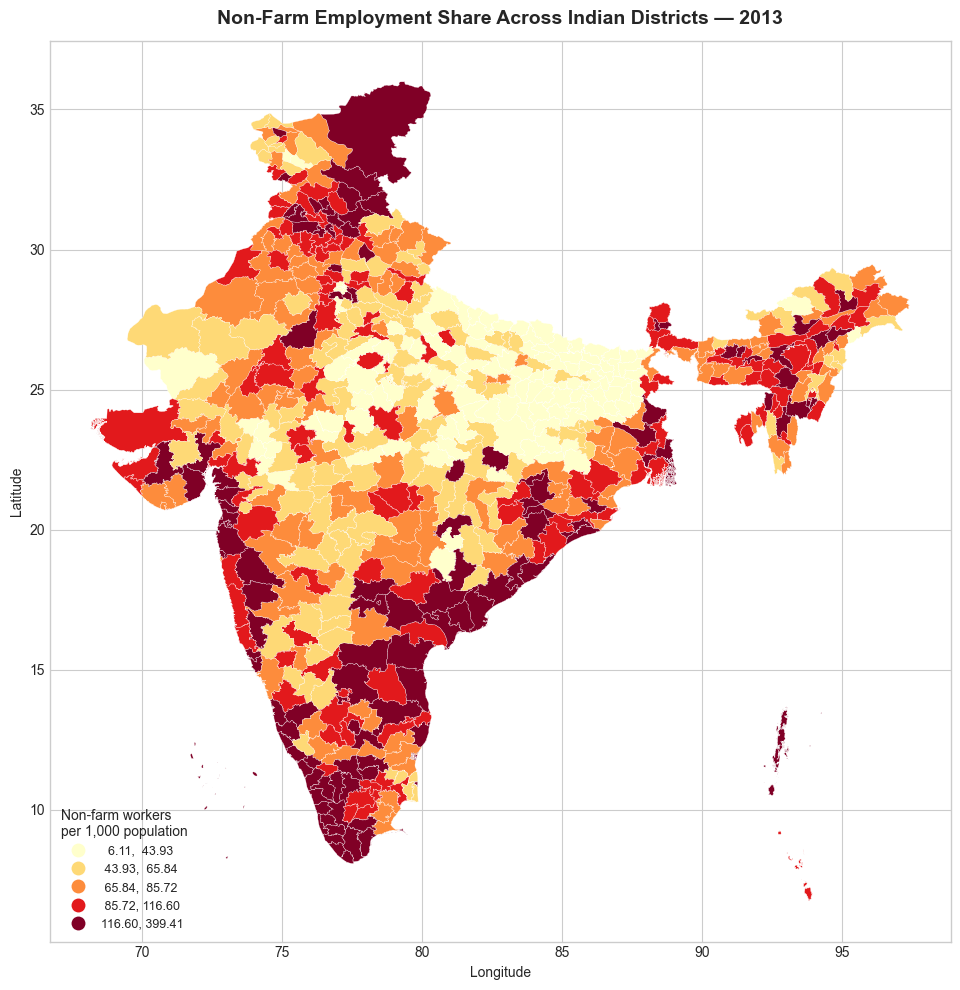

Figure saved to: ../figures/stage5_nonfarm_share_2013.png


In [21]:
# ─────────────────────────────────────────────────────────────
# Stage 5 — Exploratory choropleth: non-farm share 2013
# ─────────────────────────────────────────────────────────────

fig, ax = plt.subplots(1, 1, figsize=(14, 10))

panel.plot(
    column       = 'nonfarm_share_13',
    ax           = ax,
    scheme       = 'quantiles',
    k            = 5,
    cmap         = 'YlOrRd',
    legend       = True,
    legend_kwds  = {
        'title'     : 'Non-farm workers\nper 1,000 population',
        'loc'       : 'lower left',
        'fontsize'  : 9,
        'title_fontsize': 10,
    },
    missing_kwds = {
        'color'     : '#d0d0d0',
        'label'     : 'No data'
    },
    edgecolor    = 'white',
    linewidth    = 0.2
)

ax.set_title('Non-Farm Employment Share Across Indian Districts — 2013',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Longitude', fontsize=10)
ax.set_ylabel('Latitude', fontsize=10)
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig(FIGURES / 'stage5_nonfarm_share_2013.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure saved to: {FIGURES / 'stage5_nonfarm_share_2013.png'}")

### Stage 5 — Output

The choropleth map confirms the panel merge is correct and spatially coherent.

**Spatial patterns visible in 2013 non-farm employment share:**

- **High non-farm share (dark red, >117 per 1,000):** Concentrated in
  Gujarat's industrial coast, NCR/Delhi, Tamil Nadu, Kerala, Kashmir valley,
  and pockets around major metropolitan areas — India's industrialised and
  urbanised districts
- **Low non-farm share (pale yellow, 6–44 per 1,000):** Concentrated in
  the central and eastern interior — MP, Chhattisgarh, Jharkhand, eastern
  UP, Bihar — the agrarian heartland where structural transformation lagged

The quantile classification reveals within-country heterogeneity clearly.
This spatial variation — high along coasts and urban corridors, low in the
interior — is the core pattern Notebook 2 will map across all four EC rounds
to show how it evolved over 1990–2013.

Figure saved to `figures/stage5_nonfarm_share_2013.png`.

## Notebook 1 — Summary

This notebook accomplished five stages:

1. **Environment setup** — geopandas 1.0.1, pandas 2.3.3, matplotlib 3.9.4
2. **Shapefile loaded** — 641 district polygons (640 + 1 disputed territory),
   EPSG:4326, join key confirmed as `censuscode` = `pc11_district_id`
3. **SHRUG data loaded and inspected** — 4 EC rounds and 3 PCA rounds,
   boundary harmonisation strategy confirmed and executed
4. **Panel assembled** — 640 districts × 35 columns, all four EC rounds
   and three PCA rounds harmonised to 2011 Census boundaries via shrid-level
   crosswalk. Saved to `data/processed/districts_structural_change.gpkg`
5. **First choropleth produced** — non-farm employment share 2013 confirms
   spatially plausible merge; coastal and urban districts show highest
   structural transformation

**Ready for Notebook 2:** Structural Change Maps across all four EC rounds.